In [375]:
import os
import rmgpy.chemkin
import rmgpy.tools.uncertainty

import numpy as np

import importlib
importlib.reload(rmgpy.tools.uncertainty)

import matplotlib.pyplot as plt
%matplotlib inline

# Show that the gas-phase sensitivities match whether using RMG or Cantera

In [376]:
chemkin = '/home/moon/rmg/RMG-Py/examples/rmg/superminimal/chemkin/chem_annotated.inp'
spec_dict = '/home/moon/rmg/RMG-Py/examples/rmg/superminimal/chemkin/species_dictionary.txt'
transport = '/home/moon/rmg/RMG-Py/examples/rmg/superminimal/chemkin/tran.dat'

species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin, spec_dict, transport_path=transport)

uncertainty = rmgpy.tools.uncertainty.Uncertainty(species_list=species_list, reaction_list=reaction_list)

def get_i_thing(thing, thing_list):
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            return i
    assert False
# C2H6 = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='CC'), uncertainty.species_list)]
O2 = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='[O][O]'), uncertainty.species_list)]
H2 = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='[H][H]'), uncertainty.species_list)]
H2O = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='O'), uncertainty.species_list)]
Ar = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='[Ar]'), uncertainty.species_list)]


T = rmgpy.quantity.Quantity(1500, 'K')
P = rmgpy.quantity.Quantity(1.0, 'bar')
initial_mole_fractions = {
    # C2H6: 0.1,
    H2: 0.67,
    O2: 0.33,
    # Ar: 0.0,
}
termination_time = 0.1
sensitive_species = []
sensitive_species = [H2, H2O]
for sp in sensitive_species:
    display(sp)
 

## Run sensitivity using RMG

In [377]:
uncertainty.sensitivity_analysis(
    initial_mole_fractions,
    sensitive_species,
    T,
    P,
    termination_time,
    use_cantera=False
)

In [378]:
# load the simulation file
simulation_outfile = f'solver/simulation_1_{len(uncertainty.species_list)}.csv'
times_rmg, data_rmg = rmgpy.tools.plot.parse_csv_data(simulation_outfile)
data_labels_rmg = [d.label for d in data_rmg]

# simulation profile saves mols of core species
# https://github.com/ReactionMechanismGenerator/RMG-Py/blob/9cc2cfdedd6a7090d92782011d8f84c6292bce09/rmgpy/solver/base.pyx#L807


sens_1 = f'solver/sensitivity_1_SPC_{sensitive_species[0].index}.csv'
times1_rmg, data1_rmg = rmgpy.tools.plot.parse_csv_data(sens_1)
data_labels1_rmg = [d.label for d in data1_rmg]

sens_2 = f'solver/sensitivity_1_SPC_{sensitive_species[1].index}.csv'
times2_rmg, data2_rmg = rmgpy.tools.plot.parse_csv_data(sens_2)
data_labels2_rmg = [d.label for d in data2_rmg]

# then delete it just so there's no chance we're mixing it up with the Cantera version
os.remove(simulation_outfile)
os.remove(sens_1)
os.remove(sens_2)

# Run sensitivity using Cantera

In [379]:
uncertainty.sensitivity_analysis(
    initial_mole_fractions,
    sensitive_species,
    T,
    P,
    termination_time,
    use_cantera=True,
    cantera_file=chemkin.replace('.inp', '.yaml')
)

# load the simulation file
simulation_outfile = f'solver/simulation_1_{len(uncertainty.species_list)}.csv'
times_ct, data_ct = rmgpy.tools.plot.parse_csv_data(simulation_outfile)
data_labels_ct = [d.label for d in data_ct]

sens_1 = f'solver/sensitivity_1_SPC_{sensitive_species[0].index}.csv'
times1_ct, data1_ct = rmgpy.tools.plot.parse_csv_data(sens_1)
data_labels1_ct = [d.label for d in data1_ct]

sens_2 = f'solver/sensitivity_1_SPC_{sensitive_species[1].index}.csv'
times2_ct, data2_ct = rmgpy.tools.plot.parse_csv_data(sens_2)
data_labels2_ct = [d.label for d in data2_ct]

# then delete it just so there's no chance we're mixing it up with the Cantera version
os.remove(simulation_outfile)
os.remove(sens_1)
os.remove(sens_2)

# plot concentrations

Text(0, 0.5, 'Concentration mol/m^3')

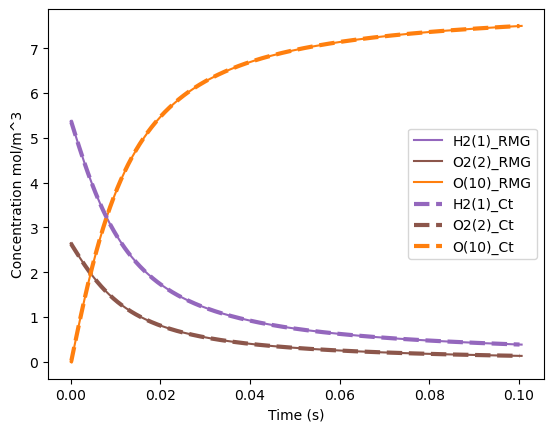

In [380]:
threshold_conc = 0.1
for i in range(len(species_list)):
    conc = np.divide(data_rmg[i + 1].data, data_rmg[0].data)
    if np.max(conc) < threshold_conc:
        continue
    plt.plot(times_rmg.data, conc, label=data_labels_rmg[i+1] + '_RMG', color=colors[i % len(colors)])


for i in range(len(species_list)):
    conc = np.divide(data_ct[i + 3].data, data_ct[0].data)
    if np.max(conc) < threshold_conc:
        continue
    plt.plot(times_ct.data, conc, label=data_labels_ct[i+3] + '_Ct', linestyle='dashed', color=colors[i % len(colors)], linewidth=3.0)
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Concentration mol/m^3')

# Plot sensitivity

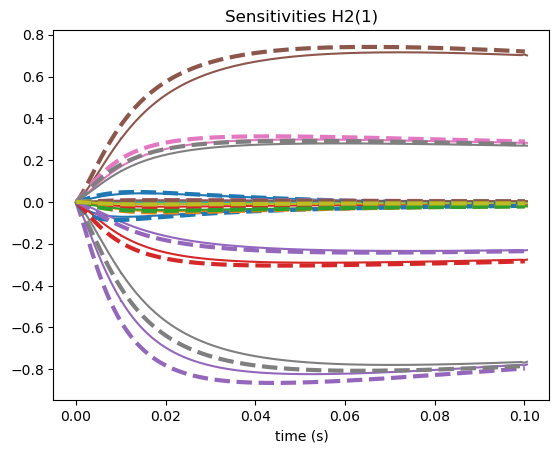

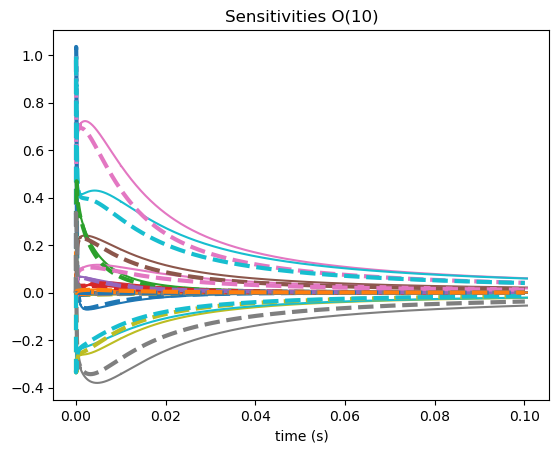

In [381]:
threshold_conc = 0.1
for i in range(len(data1_rmg)):
    plt.plot(times1_rmg.data, data1_rmg[i].data, label=data_labels1_rmg[i] + '_RMG', color=colors[i % len(colors)])

for i in range(len(data1_ct)):
    plt.plot(times1_ct.data, data1_ct[i].data, label=data_labels1_ct[i] + '_Ct', linestyle='dashed', color=colors[i % len(colors)], linewidth=3.0)

plt.title(f'Sensitivities {sensitive_species[0]}')
plt.xlabel('time (s)')
plt.show()


for i in range(len(data2_rmg)):
    plt.plot(times2_rmg.data, data2_rmg[i].data, label=data_labels2_rmg[i] + '_RMG', color=colors[i % len(colors)])

for i in range(len(data2_ct)):
    plt.plot(times2_ct.data, data2_ct[i].data, label=data_labels2_ct[i] + '_Ct', linestyle='dashed', color=colors[i % len(colors)], linewidth=3.0)

plt.title(f'Sensitivities {sensitive_species[1]}')
plt.xlabel('time (s)')
plt.show()


# Run a surface example using Cantera - no sensitivites to compare to in RMG

In [382]:
# chemkin = '../cpox_all_libs/chemkin/chem_annotated-gas.inp'
# chemkin_surf = '../cpox_all_libs/chemkin/chem_annotated-surface.inp'
# spec_dict = '../cpox_all_libs/chemkin/species_dictionary.txt'
# mech_yaml = '../cpox_all_libs/cantera/chem_annotated.yaml'


chemkin = '../../surface_sensitivities/rmg_run/chem_annotated-gas.inp'
surface = '../../surface_sensitivities/rmg_run/chem_annotated-surface.inp'
spec_dict = '../../surface_sensitivities/rmg_run/species_dictionary.txt'
mech_yaml = '../../surface_sensitivities/rmg_run/chem_annotated.yaml'
species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin, spec_dict, surface_path=surface)


gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "SURF0", [gas])

species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin, spec_dict, surface_path=chemkin_surf)

In [416]:
uncertainty = rmgpy.tools.uncertainty.Uncertainty(species_list=species_list, reaction_list=reaction_list)

def get_i_thing(thing, thing_list):
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            return i
    assert False
CH4 = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='C'), uncertainty.species_list)]
O2 = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='[O][O]'), uncertainty.species_list)]
H2 = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='[H][H]'), uncertainty.species_list)]
H2O = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='O'), uncertainty.species_list)]
Ar = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='[Ar]'), uncertainty.species_list)]
X = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='*'), uncertainty.species_list)]


termination_time = 0.1
sensitive_species = []
sensitive_species = [CH4, H2O]
for sp in sensitive_species:
    display(sp)

x_O2 = 0.2
x_CH4 = 0.1

initial_gas_mole_fractions = {O2: x_O2, CH4: x_CH4, Ar: 1.0 - x_O2 - x_CH4}
initial_surface_coverages = {X: 1.0}
T = rmgpy.quantity.Quantity((700, 'K'))
P = rmgpy.quantity.Quantity((1, 'atm'))

surface_volume_ratio = rmgpy.quantity.Quantity((1.0e5, "m^-1"))
surface_site_density = rmgpy.quantity.Quantity((surf.site_density, "kmol/m^2"))  # read from Cantera yaml just to be sure these match

termination = rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity((1.0, 's')))

In [417]:
uncertainty.sensitivity_analysis(
    initial_mole_fractions,
    sensitive_species,
    T,
    P,
    termination_time,
    use_cantera=True,
    cantera_file=mech_yaml,
    initial_surface_coverages=initial_surface_coverages,
    surface_volume_ratio=surface_volume_ratio,
)


In [418]:
# load the simulation file
simulation_outfile = f'solver/simulation_1_{len(uncertainty.species_list)}.csv'
times_ct, data_ct = rmgpy.tools.plot.parse_csv_data(simulation_outfile)
data_labels_ct = [d.label for d in data_ct]

sens_1 = f'solver/sensitivity_1_SPC_{sensitive_species[0].index}.csv'
times1_ct, data1_ct = rmgpy.tools.plot.parse_csv_data(sens_1)
data_labels1_ct = [d.label for d in data1_ct]

sens_2 = f'solver/sensitivity_1_SPC_{sensitive_species[1].index}.csv'
times2_ct, data2_ct = rmgpy.tools.plot.parse_csv_data(sens_2)
data_labels2_ct = [d.label for d in data2_ct]

# then delete it just so there's no chance we're mixing it up with the Cantera version
os.remove(simulation_outfile)
os.remove(sens_1)
os.remove(sens_2)

# Sanity check: Plot gas mole fractions to make sure they match initial spec

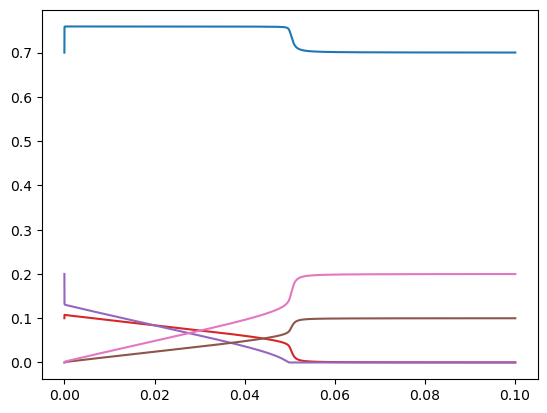

In [419]:
n_gas_sp = np.sum([not x.contains_surface_site() for x in species_list])


ct_data = np.zeros((len(data_ct[0].data), len(species_list)))
for i in range(len(species_list)):
    ct_data[:, i] = data_ct[i + 3].data
total_gas_moles = np.sum(ct_data[:, :n_gas_sp], axis=1)

threshold_conc = 1e-3
for i in range(n_gas_sp):
    mole_frac = np.divide(data_ct[i + 3].data, total_gas_moles)
    if np.max(mole_frac) < threshold_conc:
        continue
    plt.plot(times_ct.data, mole_frac, label=data_labels_ct[i+3], color=colors[i % len(colors)])

# Plot Gas concentrations and Surface coverages

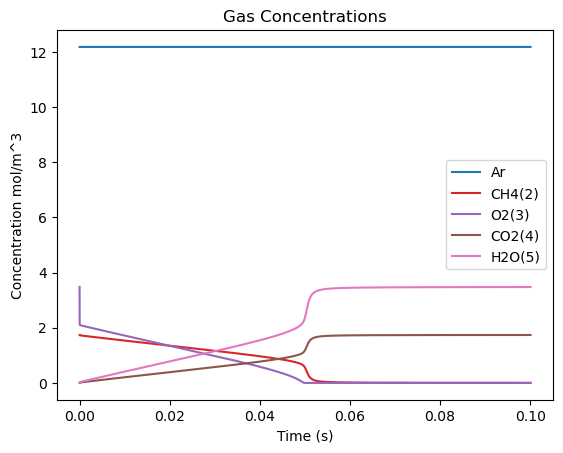

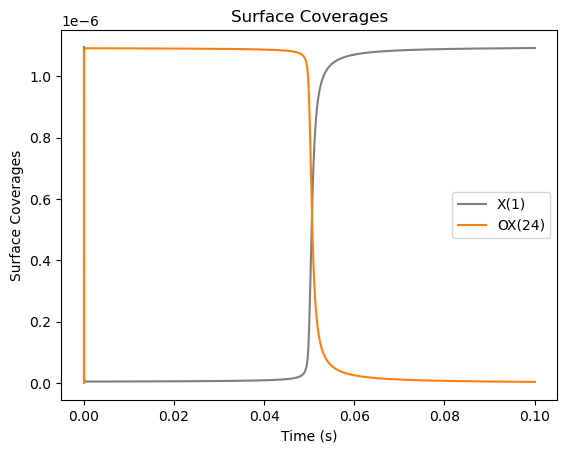

In [420]:
threshold_conc = 0.1

# Plot gas species
for i in range(n_gas_sp):
    conc = np.divide(data_ct[i + 3].data, data_ct[0].data)
    if np.max(conc) < threshold_conc:
        continue
    plt.plot(times_ct.data, conc, label=data_labels_ct[i+3], color=colors[i % len(colors)])

plt.legend()
plt.title('Gas Concentrations')
plt.xlabel('Time (s)')
plt.ylabel('Concentration mol/m^3')
plt.show()

threshold_conc = 1e-9
total_sites = data_ct[0].data * surface_volume_ratio.value_si * surface_site_density.value_si
for i in range(n_gas_sp, len(species_list)):
    conc = data_ct[i + 3].data / total_sites
    if np.max(conc) < threshold_conc:
        continue
    plt.plot(times_ct.data, conc, label=data_labels_ct[i+3], color=colors[i % len(colors)])
plt.legend()
plt.title('Surface Coverages')
plt.xlabel('Time (s)')
plt.ylabel('Surface Coverages')
plt.show()

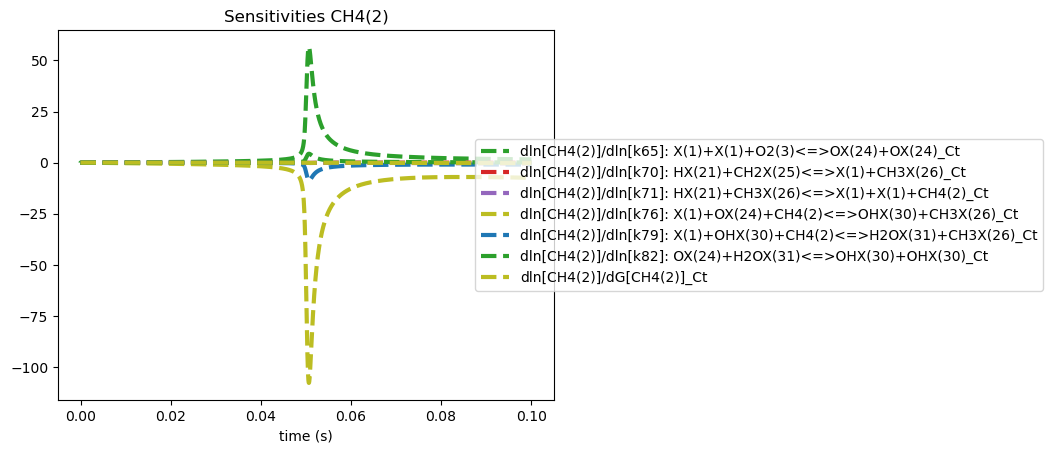

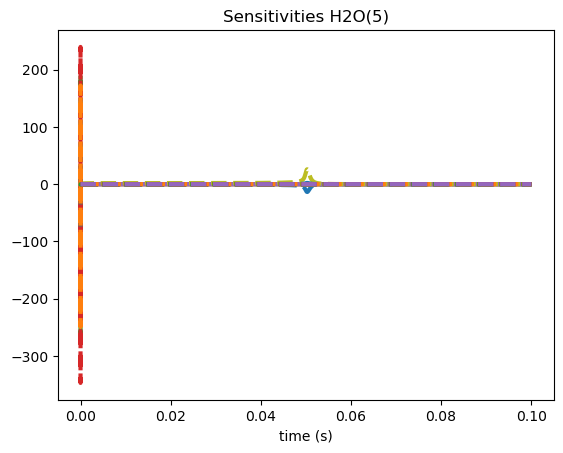

In [424]:
threshold_conc = 0.1
for i in range(len(data1_ct)):
    if np.max(np.abs(data1_ct[i].data)) < threshold_conc:
        continue
    plt.plot(times1_ct.data, data1_ct[i].data, label=data_labels1_ct[i] + '_Ct', linestyle='dashed', color=colors[i % len(colors)], linewidth=3.0)

plt.legend(loc='right', bbox_to_anchor=(2.0, 0.5))
plt.title(f'Sensitivities {sensitive_species[0]}')
plt.xlabel('time (s)')
plt.show()


for i in range(len(data2_ct)):
    plt.plot(times2_ct.data, data2_ct[i].data, label=data_labels2_ct[i] + '_Ct', linestyle='dashed', color=colors[i % len(colors)], linewidth=3.0)

plt.title(f'Sensitivities {sensitive_species[1]}')
plt.xlabel('time (s)')
plt.show()
